# Manticore-Local Cluster Posterior Catalog Demonstration

This notebook demonstrates how to work with the Manticore-Local cluster posterior catalog, which contains associations of dark matter halos identified in constrained cosmological simulations of the local universe.

## Catalog Overview

The catalog contains **1,210 raw posterior associations** identified by spatially clustering dark matter halos from 80 independent posterior realizations. Associations represent structures consistently recovered at consistent locations and masses across the posterior ensemble. Three selection tiers are provided via the `in_fiducial` and `in_strict` boolean flags in `/summary/`:

| Selection | N_assoc | Criteria |
|-----------|---------|----------|
| Raw | 1,210 | ⟨M₂₀₀⟩ ≥ 10¹⁴ M☉ |
| **Fiducial** (recommended) | **401** | + ambiguity rate < 5%, N_members ≥ 20 |
| Strict | 162 | + σ_R < 2.5 Mpc, σ_log_M < 0.25 dex |

## Catalog Structure
The HDF5 catalog contains two main groups:
- **`/summary/`**: Summary statistics (median, 25th, 75th percentiles) for each halo property across all associations, plus per-cluster scalar metadata (membership counts, selection flags, existence probability, positional scatter, etc.)
- **`/posterior/`**: Full posterior samples containing individual halo properties for each association

## Properties Stored

### Halo Properties
**Positions & Sizes** (all in Mpc):
- `BoundSubhalo_CentreOfMass`: 3D position of bound subhalo center
- `BoundSubhalo_EncloseRadius`: Radius enclosing bound particles
- `SO_200_crit_CentreOfMass`: Center of mass for R200 overdensity
- `SO_200_crit_SORadius`: R200 spherical overdensity radius
- `SO_500_crit_CentreOfMass`: Center of mass for R500 overdensity  
- `SO_500_crit_SORadius`: R500 spherical overdensity radius
- `dist`: Comoving distance from observer

**Masses** (all in M☉):
- `BoundSubhalo_TotalMass`: Total bound mass of subhalo
- `SO_200_crit_TotalMass`: M200 critical overdensity mass
- `SO_500_crit_TotalMass`: M500 critical overdensity mass

**Velocities** (in km/s):
- `BoundSubhalo_CentreOfMassVelocity`: 3D velocity of bound subhalo
- `BoundSubhalo_MaximumCircularVelocity`: Maximum circular velocity
- `SO_200_crit_CentreOfMassVelocity`: Velocity at R200
- `SO_500_crit_CentreOfMassVelocity`: Velocity at R500
- `vr`: Radial velocity

**Angular Coordinates** (all in degrees):
- `ra`: Right ascension
- `dec`: Declination  
- `gal_l`: Galactic longitude
- `gal_b`: Galactic latitude

**Dimensionless Properties**:
- `SO_200_crit_Concentration`: NFW concentration c200
- `SO_500_crit_Concentration`: NFW concentration c500
- `SO_200_crit_MassFractionSatellites`: Satellite mass fraction at R200
- `SO_200_crit_MassFractionExternal`: External mass fraction at R200
- `SO_500_crit_MassFractionSatellites`: Satellite mass fraction at R500
- `SO_500_crit_MassFractionExternal`: External mass fraction at R500

### Association Metadata (scalar fields in `/summary/` and per-association `.attrs`)
- `association_id`: Unique identifier for each association
- `n_members`: Number of member halos (one per realization; max 80)
- `existence_prob`: Fraction of realizations in which this association is recovered
- `status`: Classification — `stable`, `tentative`, `rare`, or `unknown` (stored as byte-string in per-association group `.attrs`; the `summary/status` dataset uses the integer encoding defined in the top-level attribute `status_encoding`)
- `in_fiducial`: Boolean — True for the recommended fiducial sample (401 associations)
- `in_strict`: Boolean — True for the strict sample (162 associations)
- `ambiguity_rate`: Fraction of realizations where the one-per-realization constraint was invoked (fiducial requires < 5%)
- `mean_m200_mass`: Mean M200 mass across member halos (in M☉)
- `position_std`: 3D positional scatter σ_R [x, y, z] across member halos (in Mpc)
- `log10_m200_mass_std`: Mass scatter σ_log_M across member halos (in dex)
- `center_xyz`: Comoving 3D position of the association center in simulation coordinates (in Mpc)
- `axis_ratio_ba`: Short-to-long axis ratio b/a of the member halo position distribution (1 = spherical)
- `SOAP_ProgenitorIndex`: SOAP progenitor halo index
- `SOAP_SubhaloRankByBoundMass`: Subhalo rank by bound mass

### Posterior Group Additional Fields (per-member arrays in `/posterior/association_N/`)
In addition to the halo property datasets listed above, each posterior association group contains:
- `realization_ids`: Index of the posterior realization for each member halo
- `mcmc_id`: MCMC sample identifier for each member
- `membership_probs`: DBSCAN cluster membership probabilities for each member
- `halo_original_index`: Original index of the halo in the SOAP catalog

Group-level `.attrs` on each posterior association store the scalar metadata listed above (e.g., `existence_prob`, `status`, `n_members`, `center_xyz`, `mean_m200_mass`, etc.).

## What We'll Demonstrate
1. **Loading the catalog** and understanding its hierarchical structure
2. **Visualizing association positions** using the summary statistics (RA/Dec sky distribution)
3. **Accessing posterior samples** for individual associations
4. **Analyzing halo properties** within associations (M200 mass and concentration distributions)
5. **Comparing associations** to understand population variations

The catalog enables both population-level analyses using summary statistics and detailed investigation of individual associations using the full posterior samples.

## 1. Loading the Catalog

Select a **selection tier** by setting `SELECTION` to `"raw"`, `"fiducial"`, or `"strict"`. The cell reads the HDF5 catalog and loads summary statistics (medians and percentiles) for all associations in the chosen sample. Update `catalog_path` to point to your local copy of the catalog file.

In [1]:
# Cell 1: Load the catalog data
import h5py
import numpy as np
import matplotlib.pyplot as plt
import os

# ── Selection tier ────────────────────────────────────────────────────────
# Options: "raw"      — all 1,210 associations with ⟨M200⟩ ≥ 10¹⁴ M☉
#          "fiducial" — 401 associations (ambiguity rate < 5%, N_members ≥ 20)
#          "strict"   — 162 associations (fiducial + σ_R < 2.5 Mpc, σ_logM < 0.25 dex)
SELECTION = "raw"
# ─────────────────────────────────────────────────────────────────────────

# Load the catalog file (be sure to update this with your path)
catalog_path = os.path.join("..", "output", "manticore_posterior_association_catalog.h5")

with h5py.File(catalog_path, 'r') as f:
    in_fiducial = f['summary/in_fiducial'][:]
    in_strict   = f['summary/in_strict'][:]

    if SELECTION == "raw":
        mask = np.ones(len(in_fiducial), dtype=bool)
    elif SELECTION == "fiducial":
        mask = in_fiducial
    elif SELECTION == "strict":
        mask = in_strict
    else:
        raise ValueError(f"Unknown SELECTION '{SELECTION}'. Choose 'raw', 'fiducial', or 'strict'.")

    # Load summary data (selected sample only)
    association_ids = f['summary/association_id'][:][mask]
    cluster_sizes   = f['summary/n_members'][:][mask]

    # Load median positions (RA/Dec); shape: (n_selected, 3) for [median, p25, p75]
    ra_summary  = f['summary/ra'][:][mask]
    dec_summary = f['summary/dec'][:][mask]

    # Print file structure
    print(f"Selection: '{SELECTION}'")
    print(f"Catalog structure:")
    print(f"  Selected associations : {mask.sum()} / {len(mask)} total in file")
    print(f"  Association IDs (first 10): {association_ids[:10]}...")
    print(f"  Cluster sizes: min={cluster_sizes.min()}, max={cluster_sizes.max()}, mean={cluster_sizes.mean():.1f}")
    print(f"\nAvailable summary properties: {list(f['summary'].keys())[:10]}...")
    print(f"Available associations in posterior: {len(f['posterior'].keys())}")

Selection: 'raw'
Catalog structure:
  Selected associations : 1210 / 1210 total in file
  Association IDs (first 10): [0 1 2 3 4 5 6 7 8 9]...
  Cluster sizes: min=1, max=80, mean=36.1

Available summary properties: ['BoundSubhalo_CentreOfMass', 'BoundSubhalo_CentreOfMassVelocity', 'BoundSubhalo_EncloseRadius', 'BoundSubhalo_MaximumCircularVelocity', 'BoundSubhalo_TotalMass', 'SOAP_ProgenitorIndex', 'SOAP_SubhaloRankByBoundMass', 'SO_200_crit_CentreOfMass', 'SO_200_crit_CentreOfMassVelocity', 'SO_200_crit_Concentration']...
Available associations in posterior: 1210


## 2. Sky Distribution of Associations

Sky positions (RA/Dec) of all selected associations, colour-coded by membership count (the number of posterior member halos). The left panel uses a standard cartesian projection; the right panel shows a full-sky Mollweide view. The non-uniform coverage reflects the constrained simulation's focus on the local universe around the Milky Way.

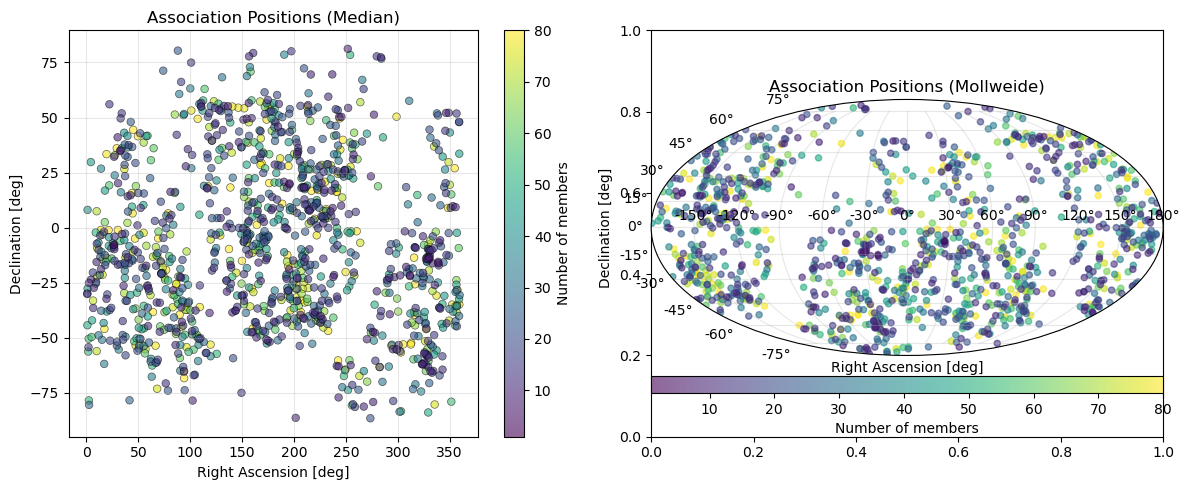

Position statistics:
  RA range: 0.8° - 359.6°
  Dec range: -86.5° - 81.2°


In [2]:
# Cell 2: Plot median positions of associations in RA/Dec
import matplotlib.pyplot as plt

# Extract median RA and Dec (first column is median)
median_ra = ra_summary[:, 0]  
median_dec = dec_summary[:, 0]

# Create figure with two subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Left: Standard scatter plot
scatter = ax1.scatter(median_ra, median_dec, c=cluster_sizes, 
                      cmap='viridis', s=30, alpha=0.6, edgecolors='black', linewidth=0.5)
ax1.set_xlabel('Right Ascension [deg]')
ax1.set_ylabel('Declination [deg]')
ax1.set_title('Association Positions (Median)')
plt.colorbar(scatter, ax=ax1, label='Number of members')
ax1.grid(True, alpha=0.3)

# Right: Mollweide projection
ax2 = plt.subplot(122, projection='mollweide')

# Convert RA to [-180, 180] for Mollweide
ra_wrapped = np.where(median_ra > 180, median_ra - 360, median_ra)
ra_rad = np.radians(ra_wrapped)
dec_rad = np.radians(median_dec)

scatter2 = ax2.scatter(ra_rad, dec_rad, c=cluster_sizes, 
                       cmap='viridis', s=20, alpha=0.6)
ax2.grid(True, alpha=0.3)
ax2.set_xlabel('Right Ascension [deg]')
ax2.set_ylabel('Declination [deg]')
ax2.set_title('Association Positions (Mollweide)')

# Set xticks in radians with degree labels
tick_labels = np.arange(-150, 181, 30)
ax2.set_xticks(np.radians(tick_labels))
ax2.set_xticklabels([f"{tl}°" for tl in tick_labels])

plt.colorbar(scatter2, ax=ax2, label='Number of members', 
             orientation='horizontal', pad=0.05, aspect=30)

plt.tight_layout()
plt.show()

# Print statistics
print(f"Position statistics:")
print(f"  RA range: {median_ra.min():.1f}° - {median_ra.max():.1f}°")
print(f"  Dec range: {median_dec.min():.1f}° - {median_dec.max():.1f}°")

## 3. Selecting an Example Association

We pick the association with the highest membership count as a worked example and load its full posterior sample from the `/posterior/` group. Each row in the posterior corresponds to a single member halo drawn from one of the 80 posterior realizations.

In [3]:
# Cell 3: Select an example association and load its posterior data
# Choose the largest association as example
example_idx = np.argmax(cluster_sizes)
example_id = association_ids[example_idx]
example_size = cluster_sizes[example_idx]

print(f"Selected association {example_id} with {example_size} members")

# Load posterior data for this association
with h5py.File(catalog_path, 'r') as f:
    association_grp = f[f'posterior/association_{example_id}']
    
    # Load M200 masses and concentrations
    m200_masses = association_grp['SO_200_crit_TotalMass'][:]
    concentrations = association_grp['SO_200_crit_Concentration'][:]
    
    # Get association metadata
    mean_m200 = association_grp.attrs['mean_m200_mass']
    mean_position = association_grp.attrs['center_xyz']
    
print(f"Association {example_id} properties:")
print(f"  Mean M200 mass: {mean_m200:.2e} M☉")
print(f"  Mean position: [{mean_position[0]:.1f}, {mean_position[1]:.1f}, {mean_position[2]:.1f}] Mpc")
print(f"  M200 range: {m200_masses.min():.2e} - {m200_masses.max():.2e} M☉")
print(f"  Concentration range: {concentrations.min():.1f} - {concentrations.max():.1f}")

Selected association 0 with 80 members
Association 0 properties:
  Mean M200 mass: 2.68e+15 M☉
  Mean position: [331.4, 430.9, 387.8] Mpc
  M200 range: 1.09e+15 - 3.87e+15 M☉
  Concentration range: 1.0 - 6.2


## 4. Posterior Distributions of Halo Properties

Histograms of M200 mass and NFW concentration (c200) across all posterior member halos of the selected association. The spread of each distribution encodes both the uncertainty in the constrained initial conditions and intrinsic scatter in halo properties across the MCMC ensemble.

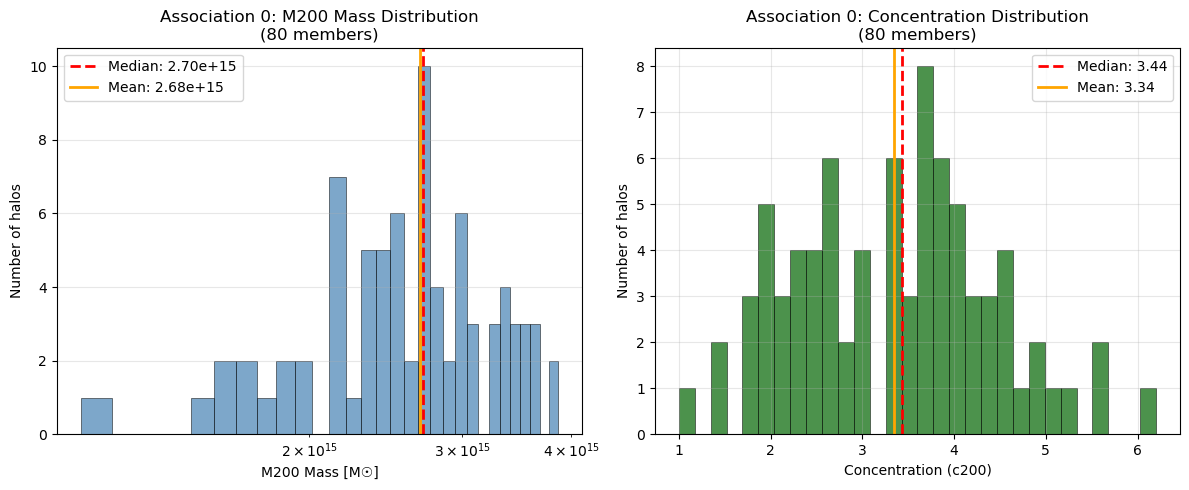


M200 Mass percentiles:
  10th: 1.89e+15 M☉
  25th: 2.32e+15 M☉
  50th: 2.70e+15 M☉
  75th: 3.05e+15 M☉
  90th: 3.48e+15 M☉

Concentration percentiles:
  10th: 1.90
  25th: 2.51
  50th: 3.44
  75th: 4.06
  90th: 4.59


In [4]:
# Cell 4: Plot posterior distributions of M200 mass and concentration
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Left: M200 mass distribution
ax1.hist(m200_masses, bins=30, alpha=0.7, color='steelblue', 
         edgecolor='black', linewidth=0.5)
ax1.axvline(np.median(m200_masses), color='red', linestyle='--', 
            linewidth=2, label=f'Median: {np.median(m200_masses):.2e}')
ax1.axvline(mean_m200, color='orange', linestyle='-', 
            linewidth=2, label=f'Mean: {mean_m200:.2e}')
ax1.set_xlabel('M200 Mass [M☉]')
ax1.set_ylabel('Number of halos')
ax1.set_title(f'Association {example_id}: M200 Mass Distribution\n({example_size} members)')
ax1.set_xscale('log')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Right: Concentration distribution
ax2.hist(concentrations, bins=30, alpha=0.7, color='darkgreen', 
         edgecolor='black', linewidth=0.5)
ax2.axvline(np.median(concentrations), color='red', linestyle='--', 
            linewidth=2, label=f'Median: {np.median(concentrations):.2f}')
ax2.axvline(np.mean(concentrations), color='orange', linestyle='-', 
            linewidth=2, label=f'Mean: {np.mean(concentrations):.2f}')
ax2.set_xlabel('Concentration (c200)')
ax2.set_ylabel('Number of halos')
ax2.set_title(f'Association {example_id}: Concentration Distribution\n({example_size} members)')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Print percentile statistics
print(f"\nM200 Mass percentiles:")
print(f"  10th: {np.percentile(m200_masses, 10):.2e} M☉")
print(f"  25th: {np.percentile(m200_masses, 25):.2e} M☉")
print(f"  50th: {np.percentile(m200_masses, 50):.2e} M☉")
print(f"  75th: {np.percentile(m200_masses, 75):.2e} M☉")
print(f"  90th: {np.percentile(m200_masses, 90):.2e} M☉")

print(f"\nConcentration percentiles:")
print(f"  10th: {np.percentile(concentrations, 10):.2f}")
print(f"  25th: {np.percentile(concentrations, 25):.2f}")
print(f"  50th: {np.percentile(concentrations, 50):.2f}")
print(f"  75th: {np.percentile(concentrations, 75):.2f}")
print(f"  90th: {np.percentile(concentrations, 90):.2f}")

## 5. Mass–Concentration Relation Across Associations

The posterior M200–c200 scatter is shown for the five most-populated associations. This illustrates how the mass–concentration relation varies between structures of different mass and large-scale environment, and gives a sense of the typical posterior uncertainty on each quantity.

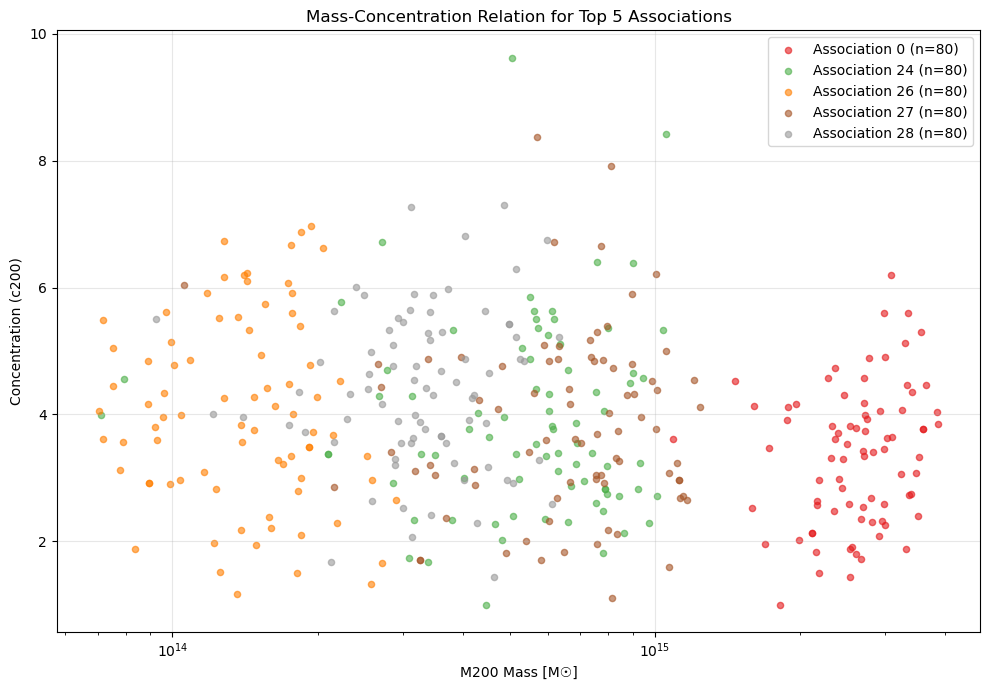

In [5]:
# Cell 5: Compare multiple associations - mass vs concentration scatter
# Select top 5 largest associations for comparison
top_n = 5
top_indices = np.argsort(cluster_sizes)[-top_n:][::-1]

fig, ax = plt.subplots(figsize=(10, 7))

colors = plt.cm.Set1(np.linspace(0, 1, top_n))

with h5py.File(catalog_path, 'r') as f:
    for i, idx in enumerate(top_indices):
        assoc_id = association_ids[idx]
        assoc_size = cluster_sizes[idx]
        
        # Load data for this association
        association_grp = f[f'posterior/association_{assoc_id}']
        masses = association_grp['SO_200_crit_TotalMass'][:]
        concs = association_grp['SO_200_crit_Concentration'][:]
        
        # Plot scatter
        ax.scatter(masses, concs, alpha=0.6, s=20, color=colors[i], 
                  label=f'Association {assoc_id} (n={assoc_size})')

ax.set_xlabel('M200 Mass [M☉]')
ax.set_ylabel('Concentration (c200)')
ax.set_title('Mass-Concentration Relation for Top 5 Associations')
ax.set_xscale('log')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 6. Comparison with Observed Clusters — Hercules Supercluster

This plot overlays Manticore-Local posterior associations with clusters from the [Abell/ACO (1989)](https://ui.adsabs.harvard.edu/abs/1989ApJS...70....1A) catalog, focusing on the Hercules Supercluster region (RA 225–250°, Dec 5–50°, z ≈ 0.025–0.035). Star markers show individual Abell clusters sized by richness class and colour-coded by redshift; scattered points show individual posterior member halos colour-coded by association ID.

> **Note — the Abell catalog must be downloaded separately.** Download the fixed-width tables from VizieR (catalogue VII/110) and place them at:
> ```
> data/abell/table3.dat   # Northern clusters
> data/abell/table4.dat   # Southern clusters
> ```
> Download from: https://cdsarc.cds.unistra.fr/viz-bin/cat/VII/110

Abell clusters in window (richness ≥ 1, with z): 6
Candidate associations (median within window + tolerance, selection='raw'): 57
Associations with ≥1 member in window: 14
Total individual members in window:    626


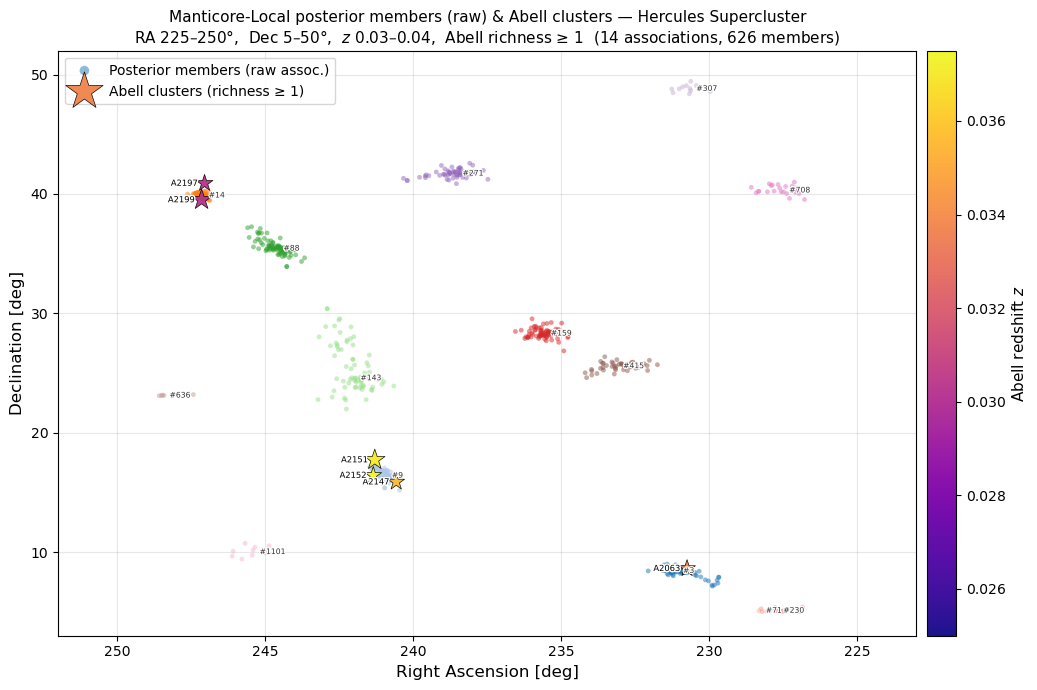

In [10]:
# Cell 6: Sky window — posterior associations overlaid on Abell clusters
import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patheffects as pe
import h5py

# ── Configurable window (edit these to explore different regions) ─────────
RA_MIN,  RA_MAX  = 225, 250   # degrees
DEC_MIN, DEC_MAX =   5,  50   # degrees
Z_MIN,   Z_MAX   = 0.025, 0.0375  # redshift
# (Hercules Supercluster: A2147/A2151/A2152 core at z~0.036, A2197/A2199 at z~0.030)

# Abell richness cut: 0=poorest (30-49 members), 1 (50-79), 2 (80-129),
#                    3 (130-199), 4 (200-299), 5=richest (300+)
RICH_MIN = 1
# ─────────────────────────────────────────────────────────────────────────

# ── 1. Parse Abell (ACO 1989) catalog ────────────────────────────────────
def parse_abell_table(filename):
    """Read an ACO fixed-width table (northern or southern)."""
    aco, ra, dec, z_out, rich_out = [], [], [], [], []
    with open(filename) as fh:
        for line in fh:
            if len(line) < 100:
                continue
            try:
                aco_num = int(line[0:4])
                ra_h    = int(line[86:88])
                ra_m    = float(line[89:93])
                dec_sgn = line[94]
                dec_d   = int(line[95:97])
                dec_m   = int(line[98:100])
                ra_deg  = (ra_h + ra_m / 60.0) * 15.0
                dec_deg =  dec_d + dec_m / 60.0
                if dec_sgn == '-':
                    dec_deg = -dec_deg
                z_str = line[133:138].strip()
                z = float(z_str) if z_str else np.nan
                rich_str = line[140:141].strip()
                r = int(rich_str) if rich_str else -1
                aco.append(aco_num); ra.append(ra_deg)
                dec.append(dec_deg); z_out.append(z); rich_out.append(r)
            except (ValueError, IndexError):
                continue
    return np.array(aco), np.array(ra), np.array(dec), np.array(z_out), np.array(rich_out)

abell_dir = os.path.join('..', 'data', 'abell')
aco3, ra3, dec3, z3, r3 = parse_abell_table(os.path.join(abell_dir, 'table3.dat'))
aco4, ra4, dec4, z4, r4 = parse_abell_table(os.path.join(abell_dir, 'table4.dat'))

abell_aco  = np.concatenate([aco3, aco4])
abell_ra   = np.concatenate([ra3, ra4])
abell_dec  = np.concatenate([dec3, dec4])
abell_z    = np.concatenate([z3, z4])
abell_rich = np.concatenate([r3, r4])

abell_mask = (
    np.isfinite(abell_z) &
    (abell_ra   >= RA_MIN) & (abell_ra   <= RA_MAX) &
    (abell_dec  >= DEC_MIN) & (abell_dec  <= DEC_MAX) &
    (abell_z    >= Z_MIN)  & (abell_z    <= Z_MAX)  &
    (abell_rich >= RICH_MIN)
)
abell_aco_w  = abell_aco[abell_mask]
abell_ra_w   = abell_ra[abell_mask]
abell_dec_w  = abell_dec[abell_mask]
abell_z_w    = abell_z[abell_mask]
abell_rich_w = abell_rich[abell_mask]

print(f"Abell clusters in window (richness ≥ {RICH_MIN}, with z): {abell_mask.sum()}")

# ── 2. Find candidate associations via summary medians + tolerance ────────
# Uses SELECTION and mask defined in Cell 1
H0, c   = 68.1, 299792.458   # km/s/Mpc, km/s  (paper cosmology)
TOL_DEG = 5.0
TOL_Z   = 0.015

with h5py.File(catalog_path, 'r') as f:
    assoc_ids   = f['summary/association_id'][:][mask]
    median_ra   = f['summary/ra'][:][mask, 0]
    median_dec  = f['summary/dec'][:][mask, 0]
    median_dist = f['summary/dist'][:][mask, 0]

median_z = median_dist * H0 / c

candidate_mask = (
    (median_ra  >= RA_MIN  - TOL_DEG) & (median_ra  <= RA_MAX  + TOL_DEG) &
    (median_dec >= DEC_MIN - TOL_DEG) & (median_dec <= DEC_MAX + TOL_DEG) &
    (median_z   >= Z_MIN   - TOL_Z)   & (median_z   <= Z_MAX   + TOL_Z)
)
candidate_ids = assoc_ids[candidate_mask]
print(f"Candidate associations (median within window + tolerance, selection='{SELECTION}'): {len(candidate_ids)}")

# ── 3. Load individual member positions for candidate associations ─────────
member_ra_all  = []
member_dec_all = []
member_z_all   = []
member_aid_all = []

with h5py.File(catalog_path, 'r') as f:
    for aid in candidate_ids:
        grp      = f[f'posterior/association_{aid}']
        ra_mem   = grp['ra'][:]
        dec_mem  = grp['dec'][:]
        z_mem    = grp['dist'][:] * H0 / c

        in_win = (
            (ra_mem  >= RA_MIN) & (ra_mem  <= RA_MAX) &
            (dec_mem >= DEC_MIN) & (dec_mem <= DEC_MAX) &
            (z_mem   >= Z_MIN)  & (z_mem   <= Z_MAX)
        )
        if in_win.sum() == 0:
            continue
        member_ra_all.append(ra_mem[in_win])
        member_dec_all.append(dec_mem[in_win])
        member_z_all.append(z_mem[in_win])
        member_aid_all.extend([aid] * in_win.sum())

member_ra  = np.concatenate(member_ra_all)
member_dec = np.concatenate(member_dec_all)
member_z   = np.concatenate(member_z_all)
member_aid = np.array(member_aid_all)

n_assoc_shown = len(np.unique(member_aid))
print(f"Associations with ≥1 member in window: {n_assoc_shown}")
print(f"Total individual members in window:    {len(member_ra)}")

# Per-association centroid (median of in-window members) for annotation
unique_aids = np.unique(member_aid)
aid_to_idx  = {aid: i for i, aid in enumerate(unique_aids)}
member_cidx = np.array([aid_to_idx[a] for a in member_aid])
assoc_colours = plt.cm.tab20(member_cidx % 20)

assoc_label_ra  = np.array([np.median(member_ra[member_aid == a])  for a in unique_aids])
assoc_label_dec = np.array([np.median(member_dec[member_aid == a]) for a in unique_aids])
assoc_label_z   = np.array([np.median(member_z[member_aid == a])   for a in unique_aids])

# ── 4. Plot ───────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(11, 7))

# Individual posterior members
ax.scatter(
    member_ra, member_dec,
    color=assoc_colours,
    s=12, alpha=0.5, linewidths=0, zorder=3,
    label=f'Posterior members ({SELECTION} assoc.)',
)

# Abell clusters — size scaled by richness class
abell_sizes = 80 + 80 * abell_rich_w
cmap_abell = plt.cm.plasma
sc_abell = ax.scatter(
    abell_ra_w, abell_dec_w, c=abell_z_w,
    cmap=cmap_abell, vmin=Z_MIN, vmax=Z_MAX,
    s=abell_sizes, marker='*', alpha=0.95,
    edgecolors='k', linewidths=0.5, zorder=4,
    label=f'Abell clusters (richness ≥ {RICH_MIN})',
)

# Abell labels: to the left of each marker
for i in range(len(abell_aco_w)):
    ax.annotate(
        f'A{abell_aco_w[i]}',
        xy=(abell_ra_w[i], abell_dec_w[i]),
        xytext=(-5, 0), textcoords='offset points',
        fontsize=6, ha='right', va='center',
        path_effects=[pe.withStroke(linewidth=2, foreground='white')],
        zorder=5,
    )

# Association labels: to the right of the member centroid
for i, aid in enumerate(unique_aids):
    ax.annotate(
        f'#{aid}',
        xy=(assoc_label_ra[i], assoc_label_dec[i]),
        xytext=(5, 0), textcoords='offset points',
        fontsize=5.5, ha='left', va='center', color='0.2',
        path_effects=[pe.withStroke(linewidth=1.5, foreground='white')],
        zorder=6,
    )

cbar = plt.colorbar(sc_abell, ax=ax, pad=0.01)
cbar.set_label('Abell redshift $z$', fontsize=11)

ax.invert_xaxis()
ax.set_xlim(RA_MAX + 2, RA_MIN - 2)
ax.set_ylim(DEC_MIN - 2, DEC_MAX + 2)
ax.set_xlabel('Right Ascension [deg]', fontsize=12)
ax.set_ylabel('Declination [deg]', fontsize=12)
ax.set_title(
    f'Manticore-Local posterior members ({SELECTION}) & Abell clusters — Hercules Supercluster\n'
    f'RA {RA_MIN}–{RA_MAX}°,  Dec {DEC_MIN}–{DEC_MAX}°,  '
    f'$z$ {Z_MIN:.2f}–{Z_MAX:.2f},  Abell richness ≥ {RICH_MIN}  '
    f'({n_assoc_shown} associations, {len(member_ra)} members)',
    fontsize=11,
)
ax.legend(fontsize=10, loc='upper left', markerscale=2)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 7. Detailed Properties of a Single Association

Prints a formatted summary of all stored properties for a chosen association. Set `ASSOCIATION_ID` to any valid association index to inspect its sky position, mass estimates, radii, concentration, and posterior scatter metrics.

In [9]:
# Cell 7: Print properties of a given association
import h5py
import numpy as np

ASSOCIATION_ID = 9   # ← change this to inspect a different association

def fmt_stat(arr, unit='', fmt='.3g'):
    """Format a [median, p25, p75] array as  median (p25 – p75)."""
    med, p25, p75 = arr
    u = f' {unit}' if unit else ''
    return f'{med:{fmt}}{u}  ({p25:{fmt}} – {p75:{fmt}}{u})'

def fmt_xyz(arr, unit='Mpc'):
    return f'[{arr[0]:.2f}, {arr[1]:.2f}, {arr[2]:.2f}] {unit}'

H0, c_kms = 68.1, 299792.458

with h5py.File(catalog_path, 'r') as f:

    # ── locate this association in the summary arrays ─────────────────────
    all_ids = f['summary/association_id'][:]
    idx = np.where(all_ids == ASSOCIATION_ID)[0]
    if len(idx) == 0:
        raise ValueError(f"Association {ASSOCIATION_ID} not found in catalog.")
    idx = idx[0]

    # ── group-level attributes (read all values inside the with block) ────
    grp    = f[f'posterior/association_{ASSOCIATION_ID}']
    status = grp.attrs['status']
    if isinstance(status, bytes):
        status = status.decode()
    status = status.strip("b'\"")

    in_fiducial      = bool(grp.attrs['in_fiducial'])
    in_strict        = bool(grp.attrs['in_strict'])
    existence_prob   = float(grp.attrs['existence_prob'])
    n_members        = int(grp.attrs['n_members'])
    ambiguity_rate   = float(grp.attrs['ambiguity_rate'])
    mean_m200_mass   = float(grp.attrs['mean_m200_mass'])
    log10_m200_std   = float(grp.attrs['log10_m200_mass_std'])
    center_xyz       = np.array(grp.attrs['center_xyz'])
    pos_std          = np.array(grp.attrs['position_std'])
    axis_ratio_ba    = float(grp.attrs['axis_ratio_ba'])

    # ── summary statistics ────────────────────────────────────────────────
    s = f['summary']
    ra_stat     = s['ra'][idx]
    dec_stat    = s['dec'][idx]
    dist_stat   = s['dist'][idx]
    vr_stat     = s['vr'][idx]
    m200_stat   = s['SO_200_crit_TotalMass'][idx]
    m500_stat   = s['SO_500_crit_TotalMass'][idx]
    r200_stat   = s['SO_200_crit_SORadius'][idx]
    r500_stat   = s['SO_500_crit_SORadius'][idx]
    c200_stat   = s['SO_200_crit_Concentration'][idx]
    c500_stat   = s['SO_500_crit_Concentration'][idx]
    mbound_stat = s['BoundSubhalo_TotalMass'][idx]
    vmax_stat   = s['BoundSubhalo_MaximumCircularVelocity'][idx]

sigma_R = float(np.sqrt(np.mean(pos_std**2)))

# ── print ─────────────────────────────────────────────────────────────────
sep = '─' * 52
print(f'Association #{ASSOCIATION_ID}')
print(sep)

print('\n  Selection & quality')
print(f'    Status          : {status}')
print(f'    In fiducial     : {in_fiducial}')
print(f'    In strict       : {in_strict}')
print(f'    Existence prob  : {existence_prob:.3f}')
print(f'    Members         : {n_members}')
print(f'    Ambiguity rate  : {ambiguity_rate:.3f}')

print('\n  Sky position  (median, p25–p75)')
z_med = dist_stat[0] * H0 / c_kms
print(f'    RA              : {fmt_stat(ra_stat, "deg", ".4g")}')
print(f'    Dec             : {fmt_stat(dec_stat, "deg", ".4g")}')
print(f'    Comoving dist   : {fmt_stat(dist_stat, "Mpc", ".4g")}')
print(f'    Redshift (med)  : z = {z_med:.4f}')
print(f'    Radial velocity : {fmt_stat(vr_stat, "km/s", ".4g")}')
print(f'    Centre XYZ      : {fmt_xyz(center_xyz)}')

print('\n  Mass  (median, p25–p75)')
print(f'    Mean M200       : {mean_m200_mass:.3e} M☉  (σ_logM = {log10_m200_std:.3f} dex)')
print(f'    M200            : {fmt_stat(m200_stat, "M☉", ".3e")}')
print(f'    M500            : {fmt_stat(m500_stat, "M☉", ".3e")}')
print(f'    Bound mass      : {fmt_stat(mbound_stat, "M☉", ".3e")}')

print('\n  Size & concentration  (median, p25–p75)')
print(f'    R200            : {fmt_stat(r200_stat, "Mpc", ".3f")}')
print(f'    R500            : {fmt_stat(r500_stat, "Mpc", ".3f")}')
print(f'    c200            : {fmt_stat(c200_stat, fmt=".3g")}')
print(f'    c500            : {fmt_stat(c500_stat, fmt=".3g")}')
print(f'    Vmax            : {fmt_stat(vmax_stat, "km/s", ".4g")}')

print('\n  Posterior scatter')
print(f'    σ_R (3D RMS)    : {sigma_R:.2f} Mpc  '
      f'[{pos_std[0]:.2f}, {pos_std[1]:.2f}, {pos_std[2]:.2f}] Mpc')
print(f'    Axis ratio b/a  : {axis_ratio_ba:.3f}')
print(sep)

Association #9
────────────────────────────────────────────────────

  Selection & quality
    Status          : stable
    In fiducial     : False
    In strict       : False
    Existence prob  : 1.000
    Members         : 80
    Ambiguity rate  : 0.163

  Sky position  (median, p25–p75)
    RA              : 241 deg  (240.9 – 241.1 deg)
    Dec             : 16.41 deg  (16.17 – 16.8 deg)
    Comoving dist   : 155.2 Mpc  (154.3 – 156.5 Mpc)
    Redshift (med)  : z = 0.0353
    Radial velocity : 85.71 km/s  (-63.55 – 236.8 km/s)
    Centre XYZ      : [427.67, 369.82, 543.85] Mpc

  Mass  (median, p25–p75)
    Mean M200       : 1.001e+15 M☉  (σ_logM = 0.151 dex)
    M200            : 1.036e+15 M☉  (8.234e+14 – 1.204e+15 M☉)
    M500            : 6.182e+14 M☉  (4.944e+14 – 7.398e+14 M☉)
    Bound mass      : 1.032e+15 M☉  (7.738e+14 – 1.266e+15 M☉)

  Size & concentration  (median, p25–p75)
    R200            : 2.125 Mpc  (1.969 – 2.234 Mpc)
    R500            : 1.319 Mpc  (1.224 – 1